### Configuration

In [1]:
import time

import sklearn

import numpy as np

import jax
import jax.numpy as jnp

import tensorflow as tf
import tensorflow.keras as K

import matplotlib.pyplot as plt

In [2]:
params = {
    "neurons": [256, 512, 1024, 512, 256, 4],
    "activations": ["tanh", "tanh", "tanh", "tanh", "tanh", "linear"],
    "epochs": 100,
    "lr": 5e-3,
    "loss": "mse",
    "batch_size": 128,
    "early_patience": 10,
    "RLRonP_factor": 0.6,
    "RLRonP_patience": 7,
}

### Pre-processing data

In [3]:
def loadData():
    return np.loadtxt("./AandB_output.txt", skiprows=1)

In [4]:
def splitData(data):
    """
    Tres datasets con una dist. de los datos 60/20/20 de la cantidad original.

    Sobol no es compatible el shuffleo de los datos, por eso se separan de esta manera.
    Se generó un solo archivo con todos los datos para no importar 3 distintos.
    """
    block = int(data.shape[0] * 0.2)
    train      = data[           : -2 * block]
    validation = data[-2 * block : -block    ]
    test       = data[-block     :           ]
    return train, validation, test

In [5]:
def _createScaler():
    """
    Se crea un Scaler global para toda la instancia y se impiden problemas con la aleatoriedad.
    """
    global SSi, SSo
    SSi = sklearn.preprocessing.StandardScaler()
    SSo = sklearn.preprocessing.StandardScaler()
    return 0

In [6]:
def scaleData(data_set):
    """
    Divide los 6 imputs y 4 outputs ded cada data set.

    Se crea 2 SS y 2 scalers para input y output. Los scalers solo se crean con train
    para impedir que el modelo sepa de antemano información de validation o test.
    """
    i_set, o_set = data_set[:,:6], data_set[:,6:]    # (z, k1, k2, x12, om, logf), (A, Ap, B, Bp)

    if "SSi" not in globals() and "SSo" not in globals():    # <---Claude
        _createScaler()

        global scaler_i, scaler_o
        scaler_i = SSi.fit(i_set)
        scaler_o = SSo.fit(o_set)
        
    return [scaler_i.transform(i_set), scaler_o.transform(o_set)]

### Model & training

In [7]:
def _createModel():
    """
    La arquitectura de la red está descrita por el dict arqui. 
    
    Es mutables para realizar muchas pruebas, pero el input y output siempre son los mismo.
    """
    neurons     = params["neurons"]
    activations = params["activations"]
    lr          = params["lr"]
    loss        = params["loss"]

    model = K.Sequential()
    model.add(K.Input(shape=(6,)))
    for n, func in zip(neurons, activations):
        model.add(K.layers.Dense(n, activation=func))

    model.compile(
        optimizer=K.optimizers.Adam(learning_rate=lr),
        loss=loss
    )

    model.summary()
    return model

In [8]:
def _callbacks():
    ES = K.callbacks.EarlyStopping
    RLRonP = K.callbacks.ReduceLROnPlateau

    early_patience  = params["early_patience"]
    RLRonP_factor   = params["RLRonP_factor"]
    RLRonP_patience = params["RLRonP_patience"]
    
    call_1 = ES(
        monitor               = 'val_loss',
        mode                  = "min",
        patience              = early_patience,
        restore_best_weights  = True,
        verbose               = 1,
    )

    call_2 = RLRonP(
        monitor   = 'val_loss',
        factor    = RLRonP_factor,
        patience  = RLRonP_patience,
        min_lr    = 1e-6,
        verbose   = 1
    )
            
    return [call_1, call_2]

In [9]:
def trainModel(scaled_train, scaled_val):
    """
    shuffle=True no afecta a Sobol ya que solo está cambiando el orden de cada uno de los sets,
    pero cada set ya está cubriendo todo el espacio.
    """
    epochs     = params["epochs"]
    batch_size = params["batch_size"]

    x_train, y_train = scaled_train[0], scaled_train[1]
    x_val, y_val     = scaled_val[0], scaled_val[1]
    model = _createModel()

    history = model.fit(
        x_train, y_train,
        batch_size=batch_size,
        epochs=epochs,
        shuffle=True,
        validation_data=(x_val, y_val),
        verbose=2,
        callbacks=_callbacks(),
    )

    return history, model

### Post-processing data

In [10]:
def unScaleData(data):
    """
    Aplica el escalamiento inverso para obtener los valores en los rangos originales.
    """
    return scaler_o.inverse_transform(data)

### Data validation

In [11]:
def _makePrediction(model, x_data):
    batch_size = params["batch_size"]

    prediction = model.predict(
        x_data,
        batch_size=batch_size,
        verbose=0,
    )

    return prediction

In [12]:
def relError(model, scaled_data):
    scaled_x, scaled_y = scaled_data[0], scaled_data[1]
    scaled_y_predic    = _makePrediction(model, scaled_x)

    unscaled_y         = unScaleData(scaled_y)
    unscaled_y_predic  = unScaleData(scaled_y_predic)
        
    #unscaled_rel_error = (unscaled_y - unscaled_y_predic) * 100
    unscaled_rel_error = (1 - unscaled_y_predic / unscaled_y) * 100

    return unscaled_rel_error

In [13]:
def calcPercentil(error):
    rows = 4
    r_names = ["A", "Ap", "B", "Bp"]

    print(f"Percentil 99 for unscaled data in absolute percentual error")
    print(20 * "=")
    for r in range(rows):        
        perc = np.percentile(error.T[r], 99)
        print(f"{r_names[r]:>4}: {perc:.6f}%")
    print(20 * "=")

### Plotting

In [14]:
def plotLossFunction(history):
    succ_epochs = len(history.history['loss'])
    plt.figure(figsize=(10,7))
    x_axis = np.linspace(1, succ_epochs, succ_epochs)
    plt.semilogy(x_axis, history.history['loss'], 'r--', label='Train')
    plt.semilogy(x_axis, history.history['val_loss'], 'b-', label='Validation')
    plt.legend()
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.show()

In [15]:
def plotRelError(rel_error):
    rows, cols = 2, 2
    names = ["A", "Aprime", "B", "Bprime"]
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 16))

    for c in range(cols):
        for r in range(rows):
            axes[r, c].hist(
                rel_error.T[r * 2 + c],
                bins=40,
                #range=(-1, 1),
                log=True,
                orientation="horizontal",
            )
            axes[r, c].set_xlabel("Frecuency", fontsize=18)
            axes[r, c].set_ylabel(r"$\Delta y$%", fontsize=18)
            axes[r, c].tick_params(
                axis="both",
                labelsize=14,
            )
            axes[r, c].set_title(f"Error relativo porcentual de {names[r * 2 + c]}")
    
    plt.savefig("rel_error.png", dpi=600)
    plt.show()

### Evaluation

In [16]:
data = loadData()
train, validation, test = splitData(data)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,315,844 (5.02 MB)

 Trainable params: 1,315,844 (5.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
77/77 - 30s - 394ms/step - loss: 0.7991 - val_loss: 0.7572 - learning_rate: 1.0000e-04
Epoch 2/100
77/77 - 1s - 7ms/step - loss: 0.6547 - val_loss: 0.4977 - learning_rate: 1.0000e-04
Epoch 3/100
77/77 - 0s - 6ms/step - loss: 0.3267 - val_loss: 0.2231 - learning_rate: 1.0000e-04
Epoch 4/100
77/77 - 0s - 5ms/step - loss: 0.1862 - val_loss: 0.1569 - learning_rate: 1.0000e-04
Epoch 5/100
77/77 - 0s - 6ms/step - loss: 0.1411 - val_loss: 0.1254 - learning_rate: 1.0000e-04
Epoch 6/100
77/77 - 0s - 6ms/step - loss: 0.1132 - val_loss: 0.1014 - learning_rate: 1.0000e-04
Epoch 7/100
77/77 - 0s - 6ms/step - loss: 0.0915 - val_loss: 0.0809 - learning_rate: 1.0000e-04
Epoch 8/100
77/77 - 0s - 6ms/step - loss: 0.0748 - val_loss: 0.0669 - learning_rate: 1.0000e-04
Epoch 9/100
77/77 - 0s - 6ms/step - loss: 0.0616 - val_loss: 0.0575 - learning_rate: 1.0000e-04
Epoch 10/100
77/77 - 0s - 6ms/step - loss: 0.0519 - val_loss: 0.0485 - learning_rate: 1.0000e-04
Epoch 11/100
77/77 - 0s - 6ms/step -

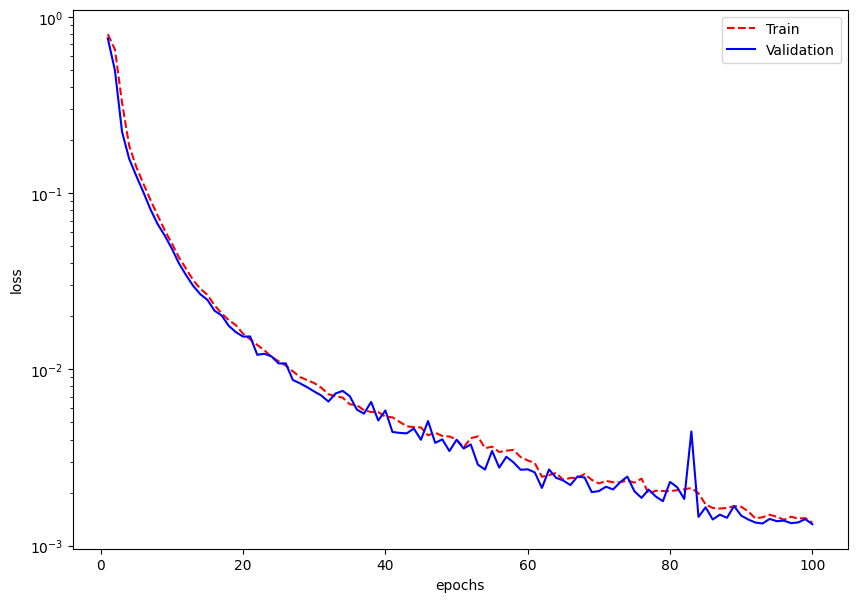

CPU times: user 2min 30s, sys: 50.6 s, total: 3min 20s
Wall time: 1min 19s


In [17]:
%%time
scaled_train = scaleData(train)
scaled_val = scaleData(validation)

history, model = trainModel(scaled_train, scaled_val)
plotLossFunction(history)

Percentil 99 for unscaled data in absolute percentual error
   A: 0.202841%
  Ap: 91.678063%
   B: 0.083954%
  Bp: 80.218073%


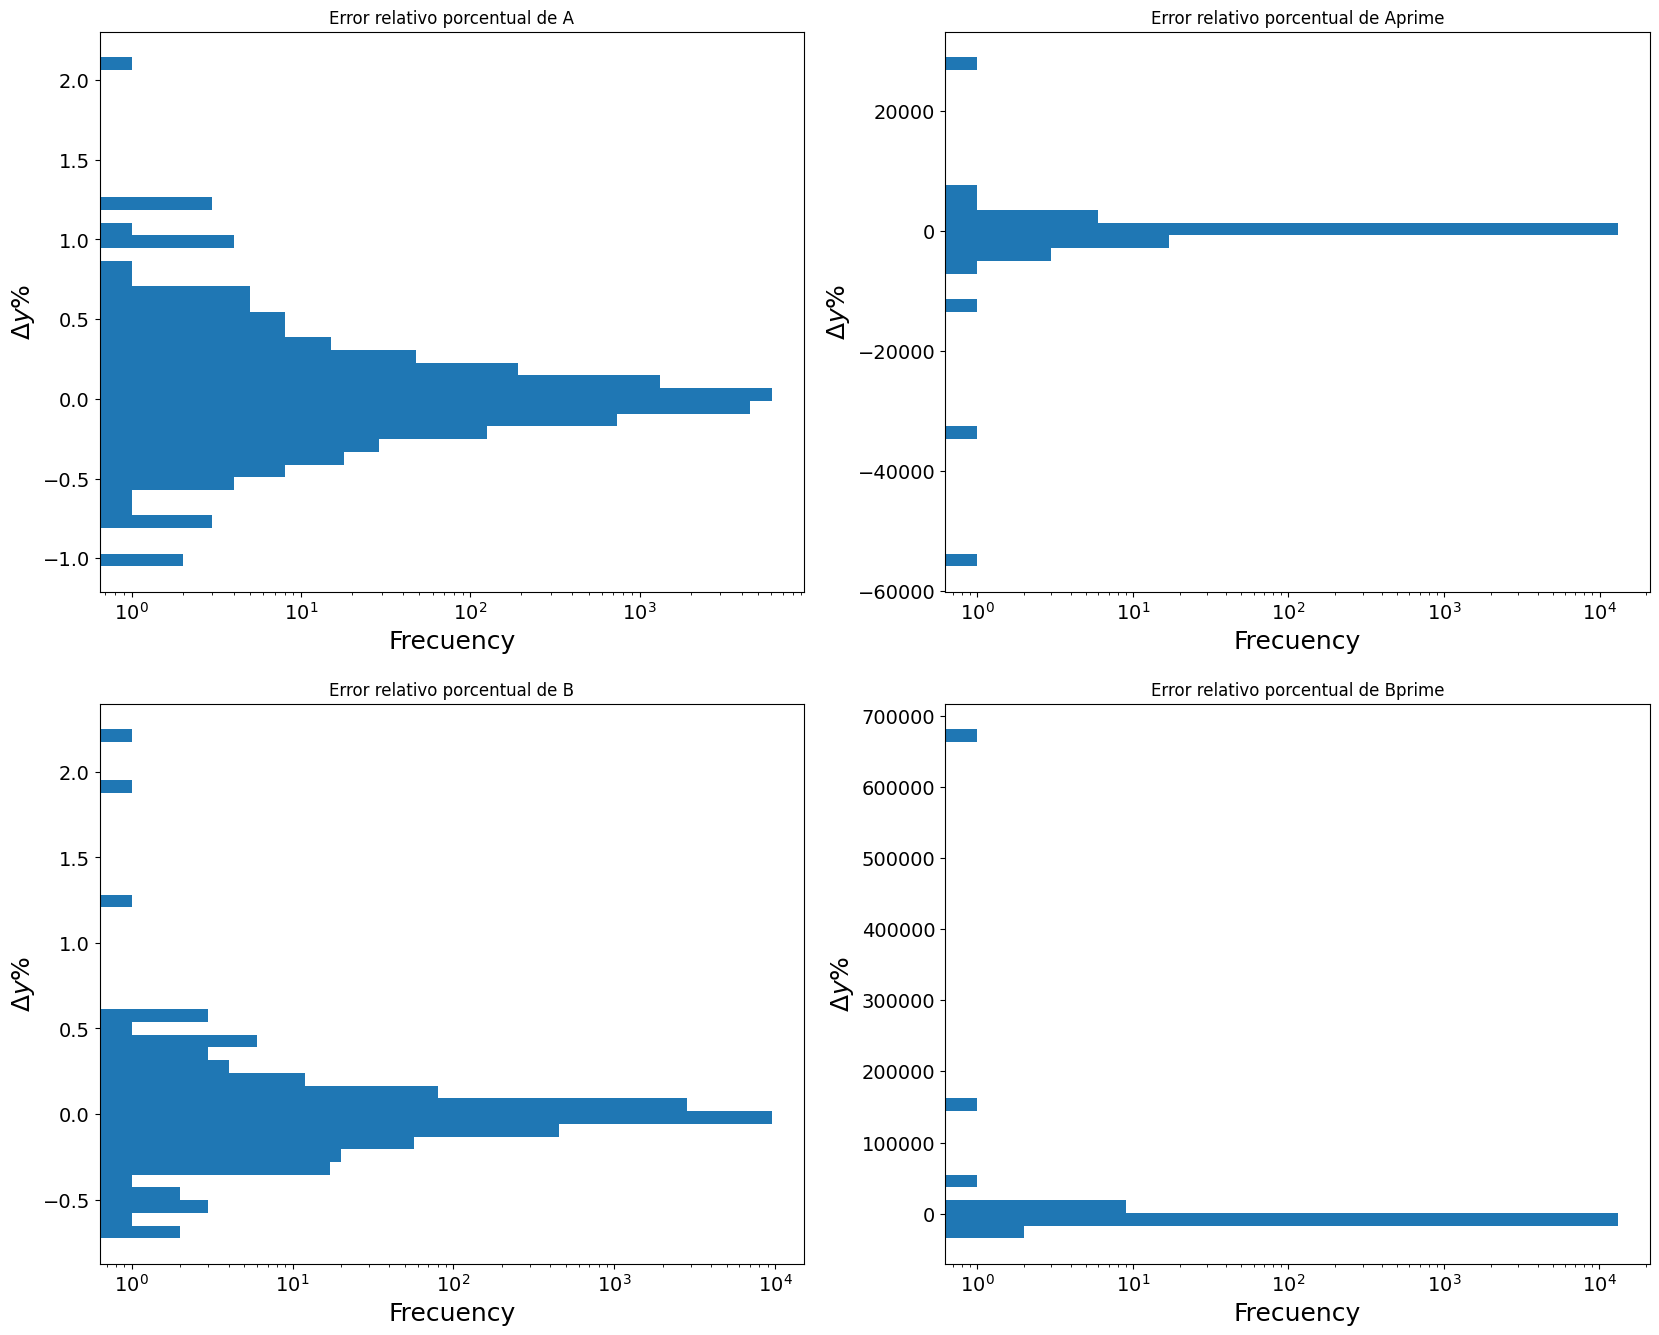

CPU times: user 6.19 s, sys: 885 ms, total: 7.07 s
Wall time: 6.61 s


In [18]:
%%time
scaled_test = scaleData(test)

rel_error = relError(model, scaled_test)
calcPercentil(rel_error)
plotRelError(rel_error)

82
0.625620%


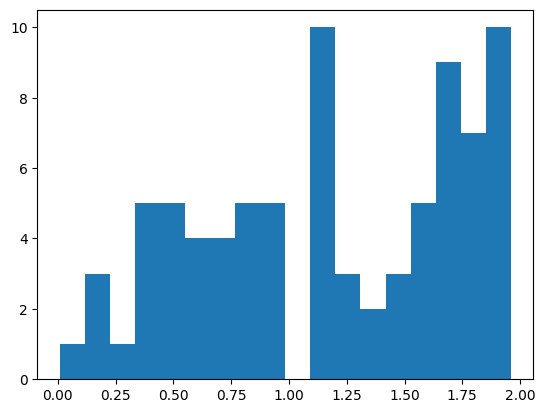

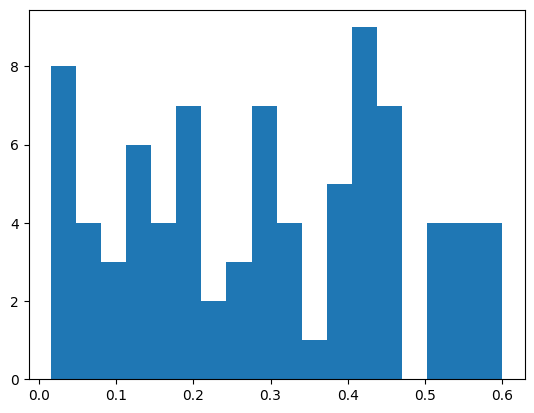

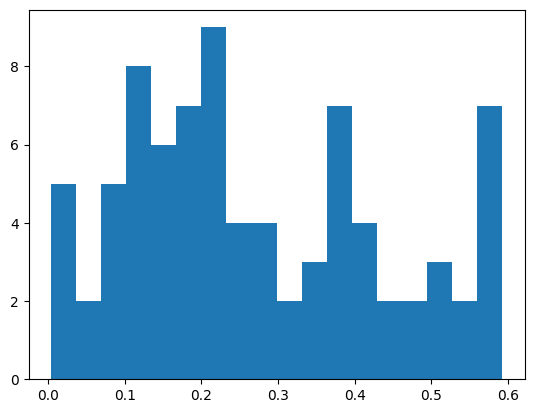

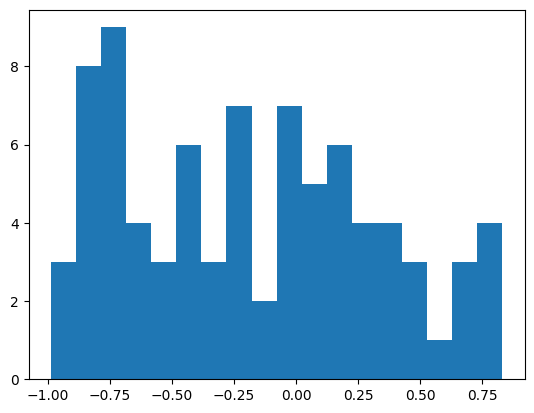

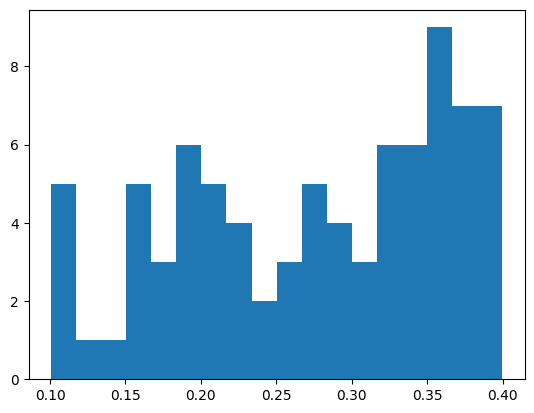

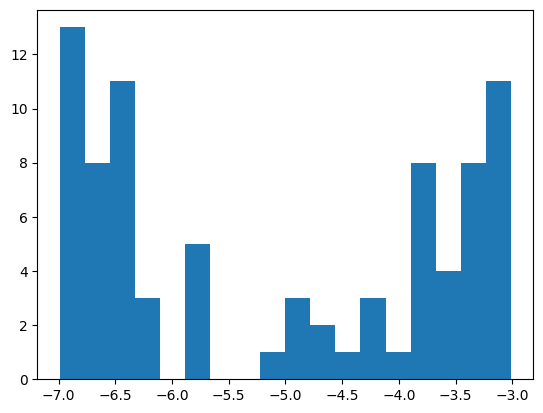

154
1.174945%


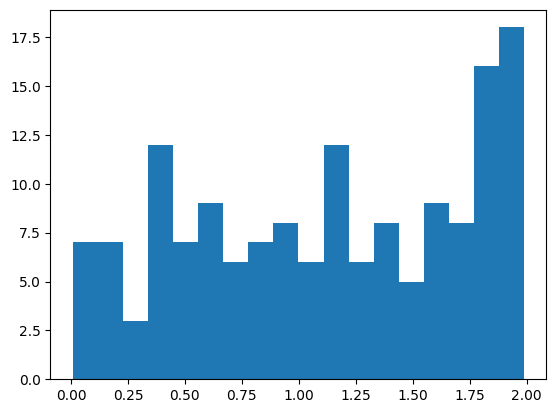

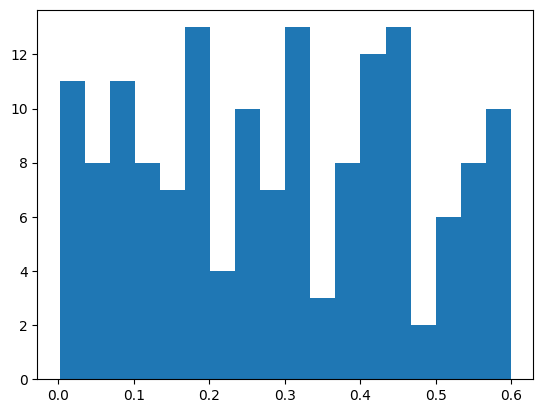

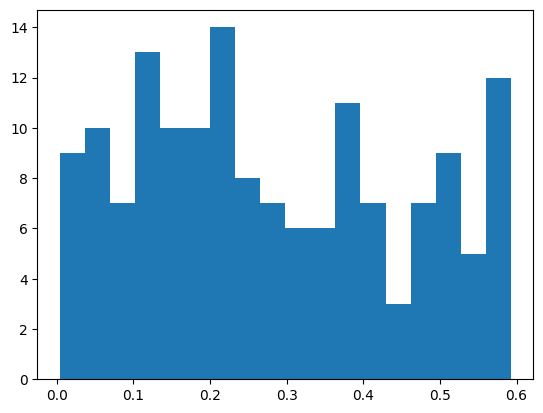

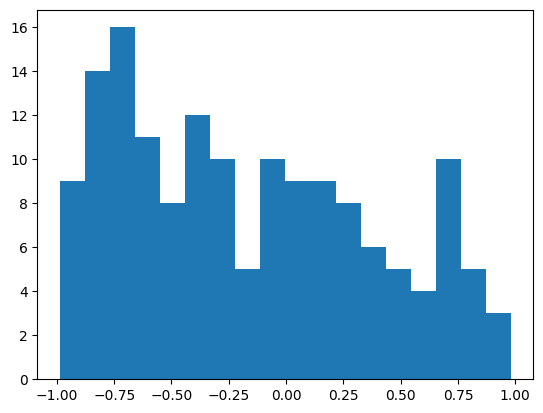

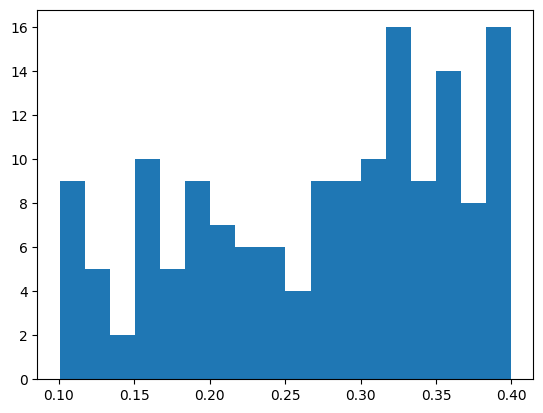

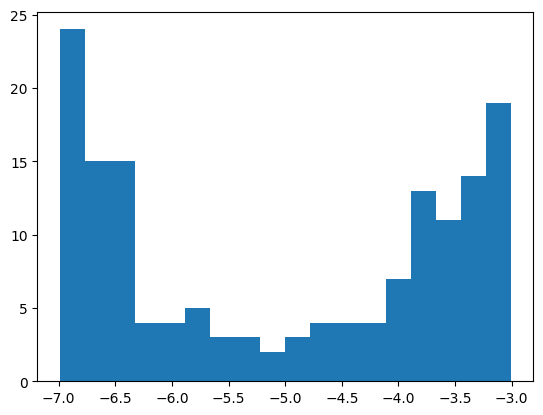

In [19]:
"""
Estudio de las anomalías
"""
rel_error_Ap, rel_error_Bp = rel_error.T[1,:], rel_error.T[3,:]

count = 0
values = []
idx_Ap = []
for idx, e in enumerate(rel_error_Ap):
    if e > 130:
        count += 1
        values.append(e)
        idx_Ap.append(idx)

print(count)
print(f"{count/test.shape[0] * 100:.6f}%")
for i in range(6):
    plt.hist(
        test[idx_Ap,i],
        bins=18
    )
    plt.show()

count = 0
values = []
idx_Bp = []
for idx, e in enumerate(rel_error_Ap):
    if e > 76:
        count += 1
        values.append(e)
        idx_Bp.append(idx)

print(count)
print(f"{count/test.shape[0] * 100:.6f}%")
for i in range(6):
    plt.hist(
        test[idx_Bp,i],
        bins=18
    )
    plt.show()

Percentil 99 for unscaled data in absolute percentual error
   A: 0.102725%
  Ap: 133.658901%
   B: 0.108739%
  Bp: 26.918799%


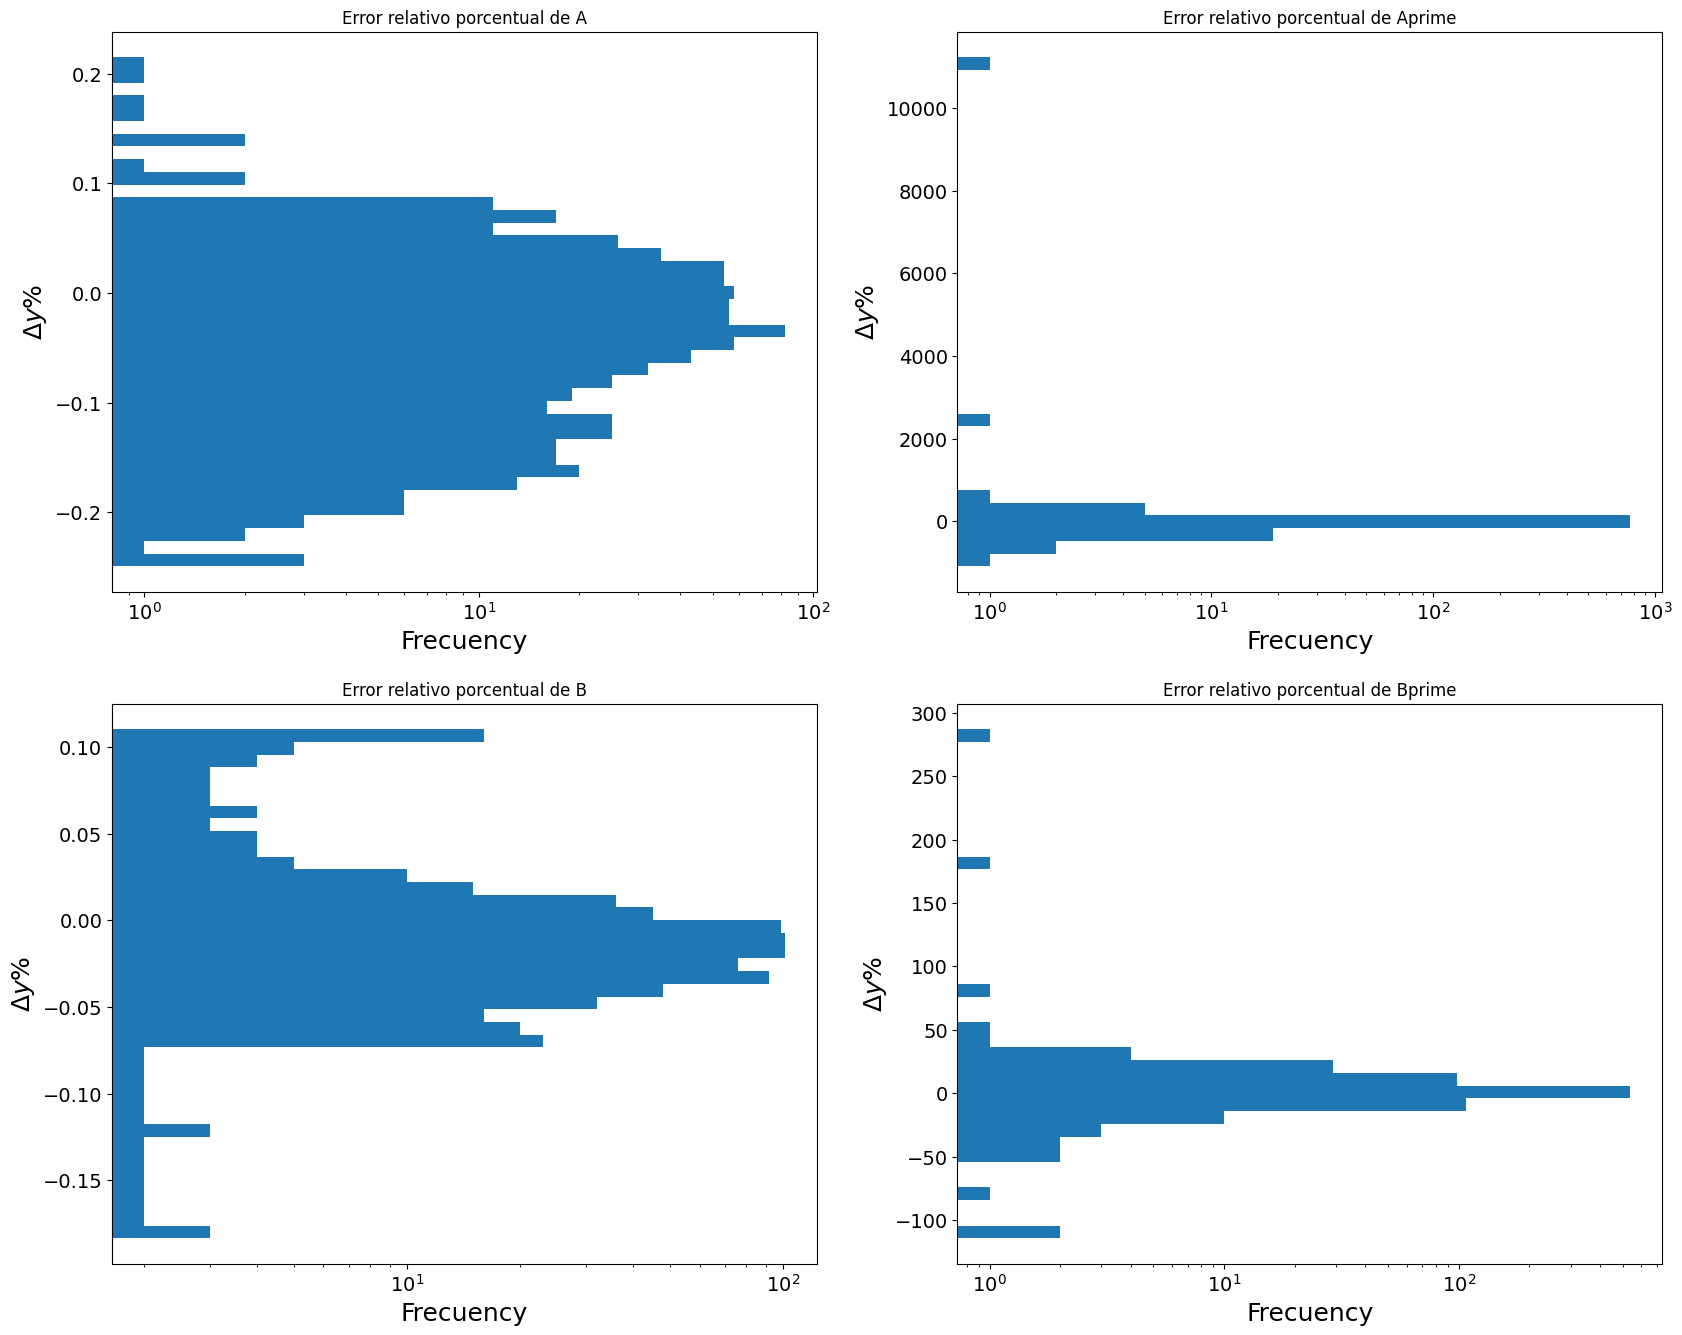

In [20]:
f = np.loadtxt("./AandB_curves.txt", skiprows=1)

z_arr = f.T[0,:100]

cosmo, curves = f[:,:6], f[:,6:]
cosmo = [cosmo[0], cosmo[100], cosmo[200], cosmo[300], cosmo[400], cosmo[500], cosmo[600], cosmo[700]]

scaled_curves = scaleData(f)
scaled_curves_predic = _makePrediction(model, scaled_curves[0])
unscaled_curves_predic = unScaleData(scaled_curves_predic)

rel_error = relError(model, scaled_curves)
calcPercentil(rel_error)
plotRelError(rel_error)

A_arr = []
A_arr_predic = []

Ap_arr = []
Ap_arr_predic = []

B_arr = []
B_arr_predic = []

Bp_arr = []
Bp_arr_predic = []
for c in range(7):
    A_arr.append(curves.T[0, c*100:(c+1)*100])
    A_arr_predic.append(unscaled_curves_predic.T[0, c*100:(c+1)*100])
    
    Ap_arr.append(curves.T[1, c*100:(c+1)*100])
    Ap_arr_predic.append(unscaled_curves_predic.T[1, c*100:(c+1)*100])
    
    B_arr.append(curves.T[2, c*100:(c+1)*100])
    B_arr_predic.append(unscaled_curves_predic.T[2, c*100:(c+1)*100])
    
    Bp_arr.append(curves.T[3, c*100:(c+1)*100])
    Bp_arr_predic.append(unscaled_curves_predic.T[3, c*100:(c+1)*100])

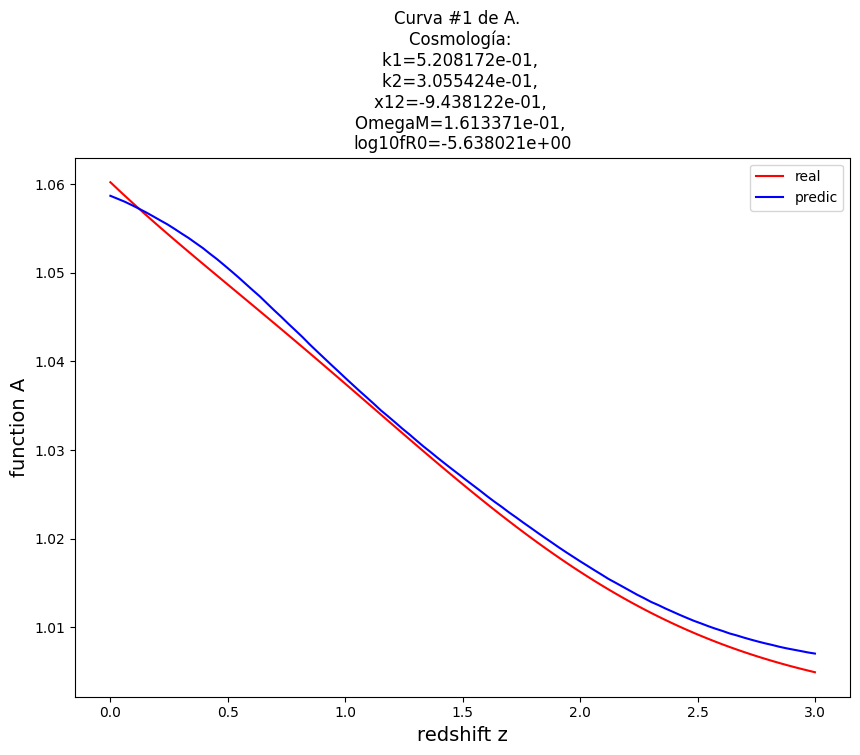

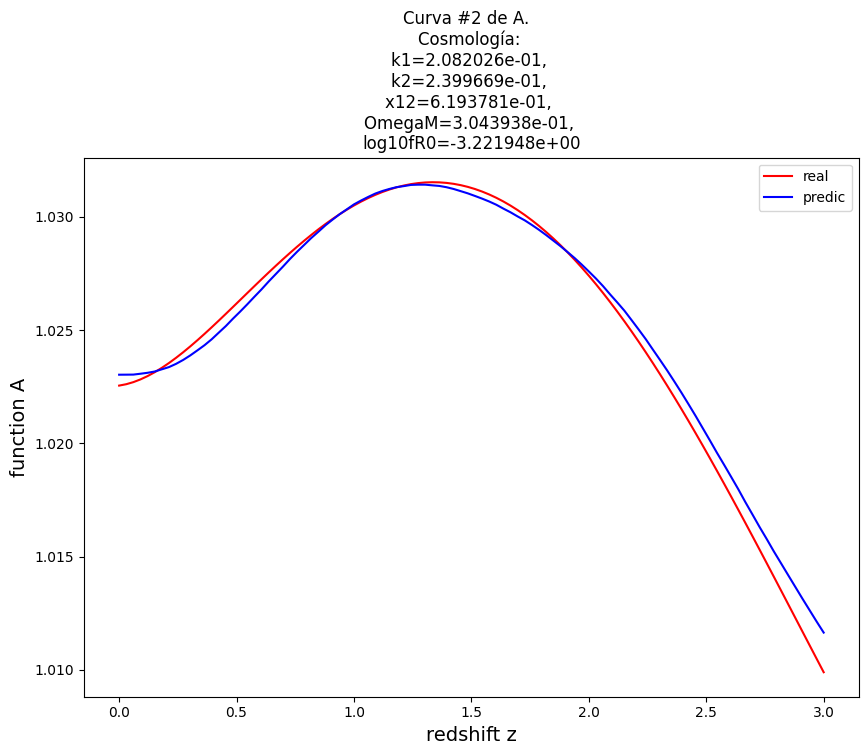

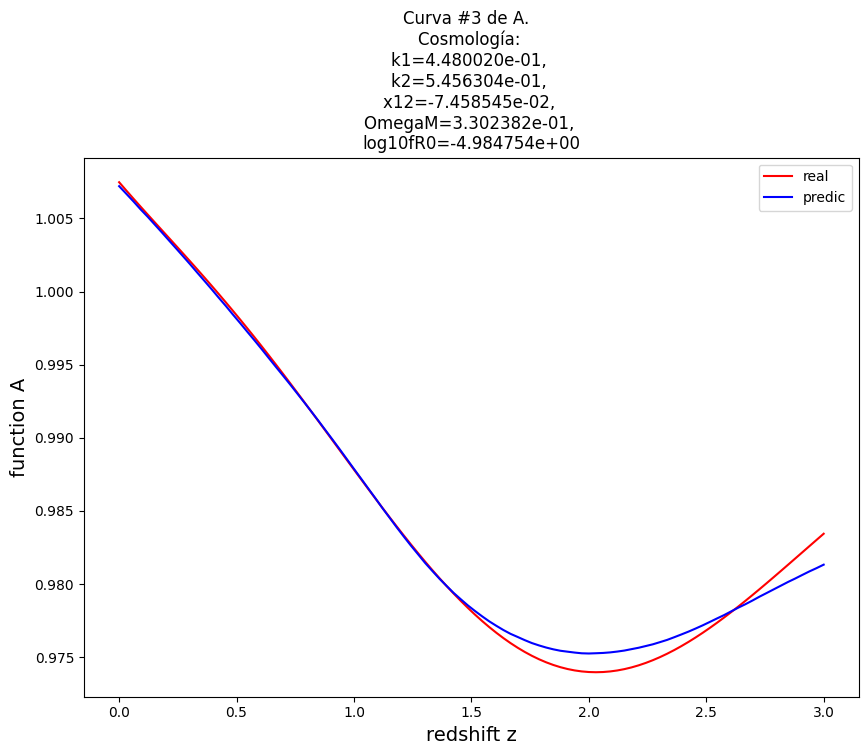

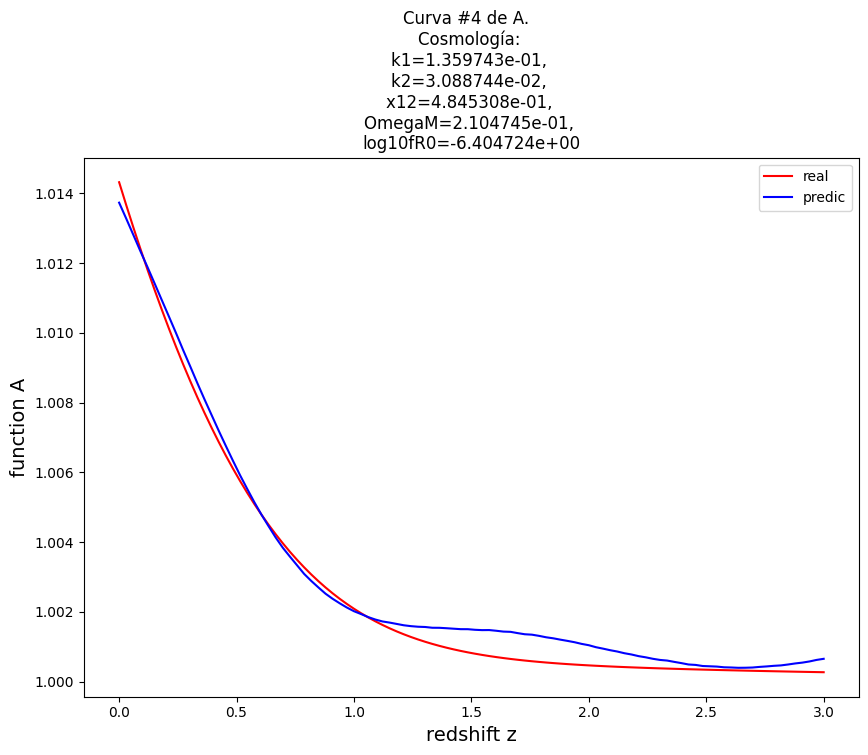

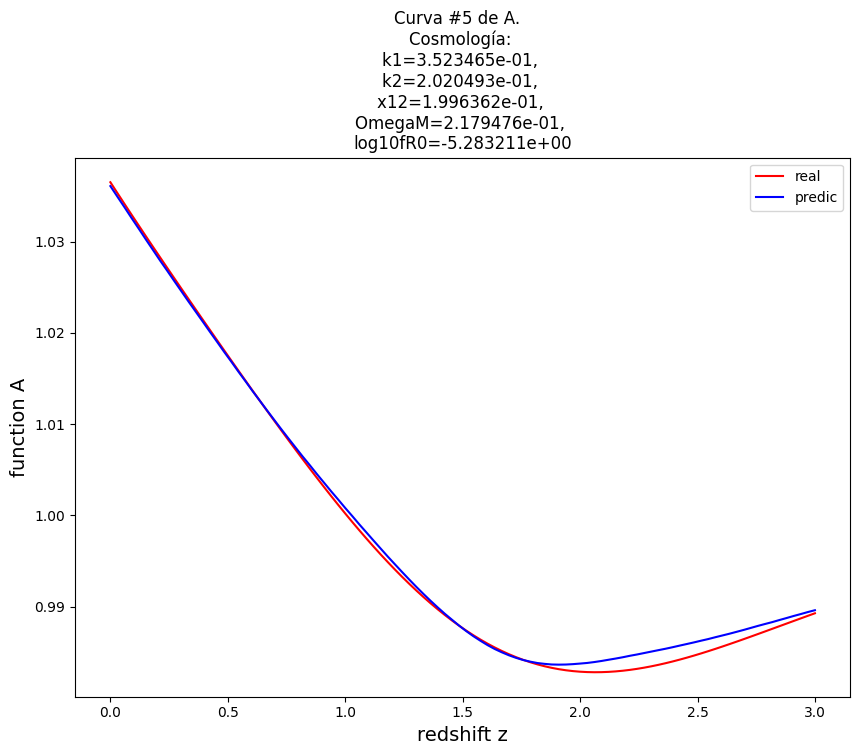

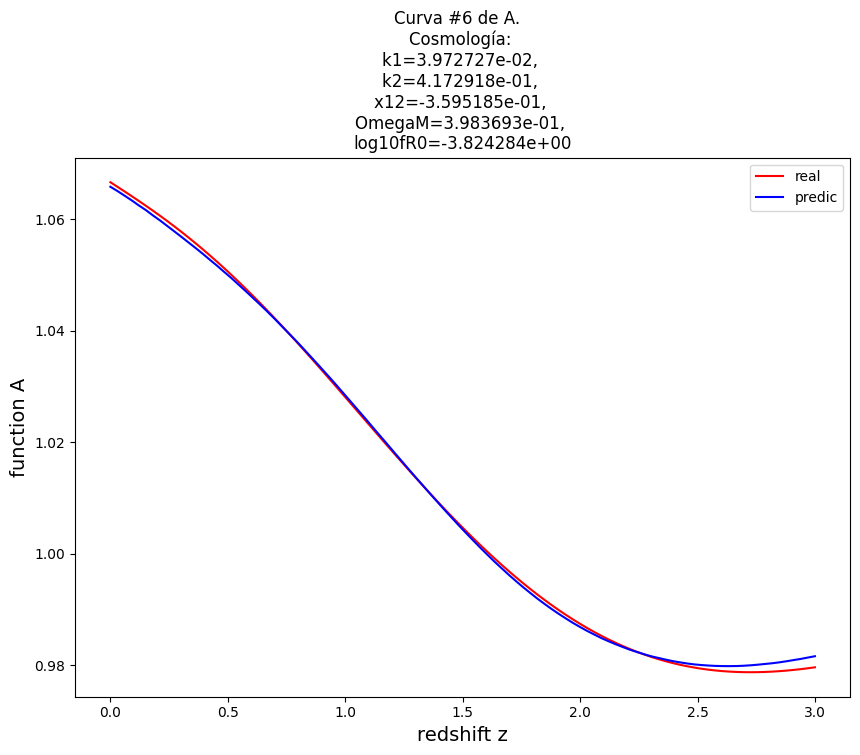

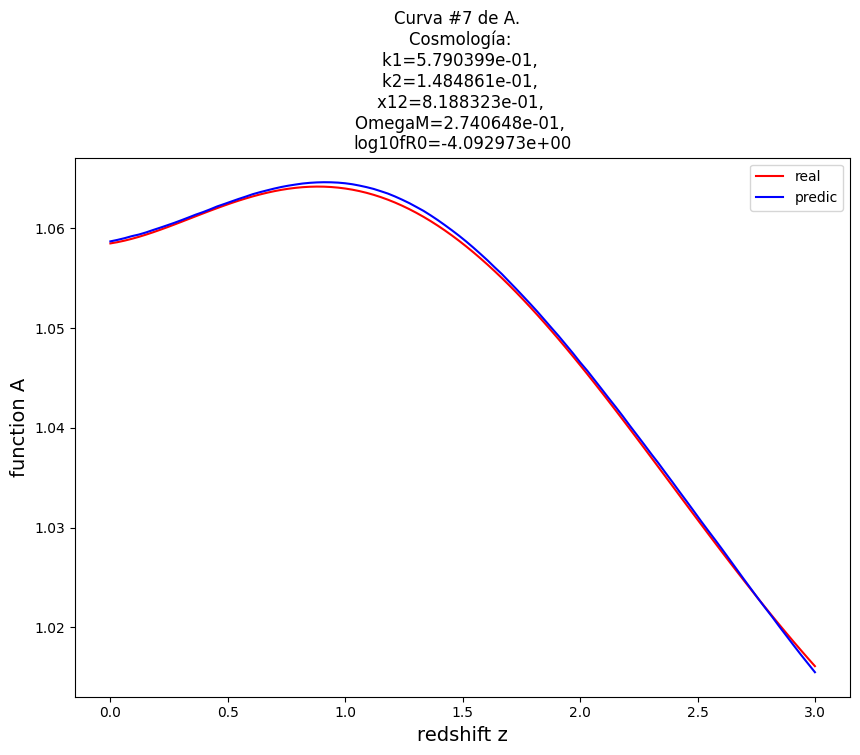

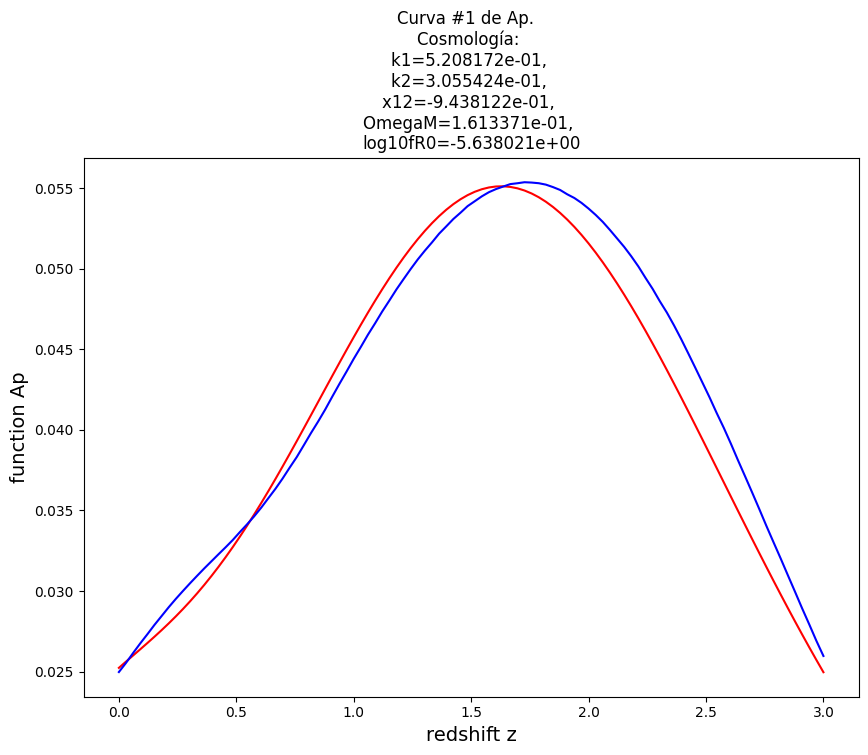

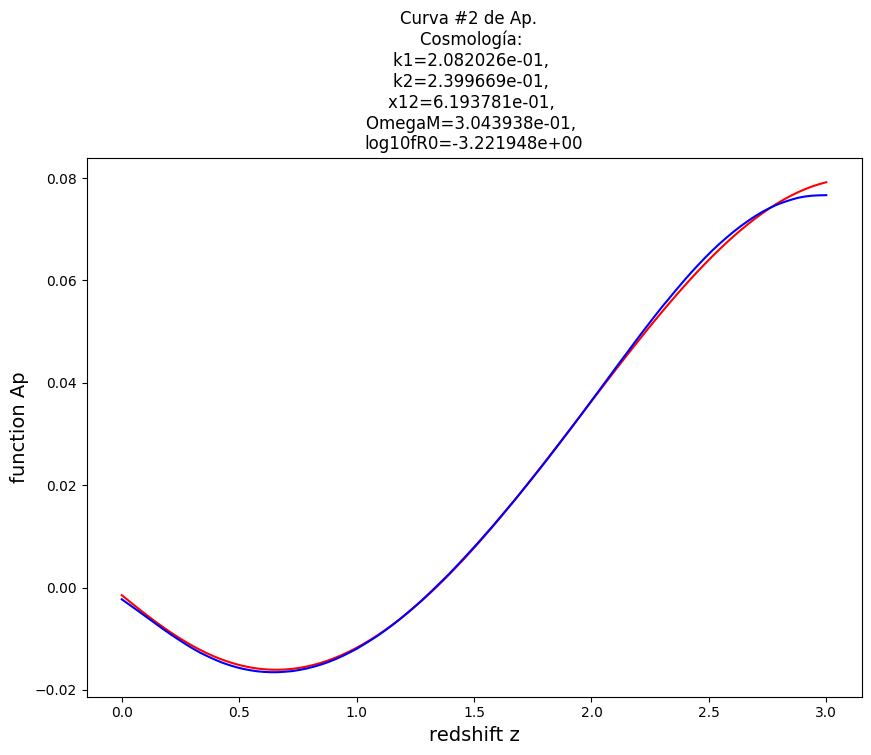

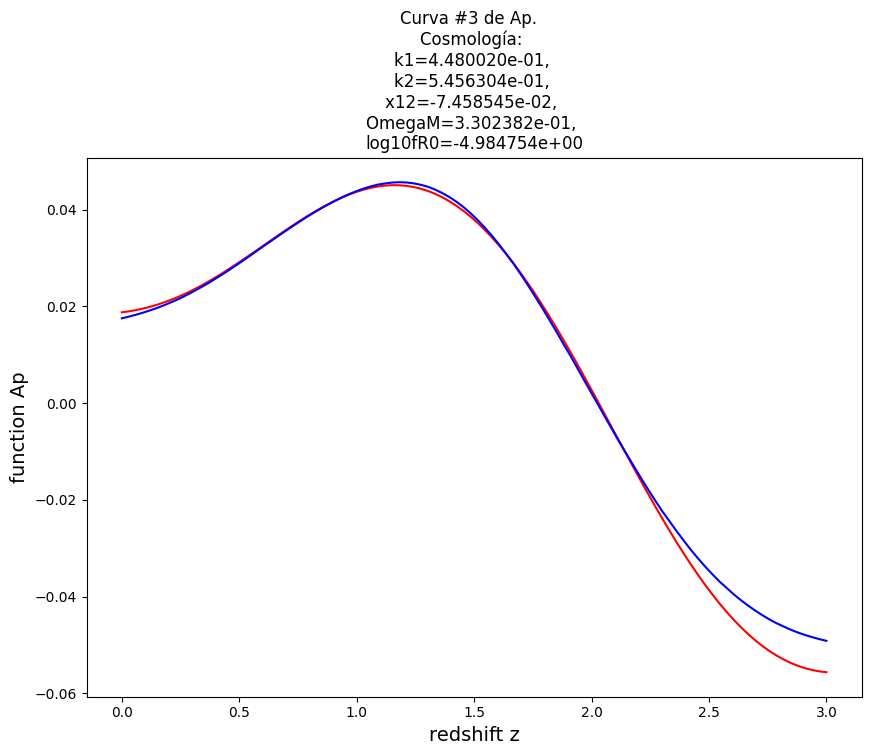

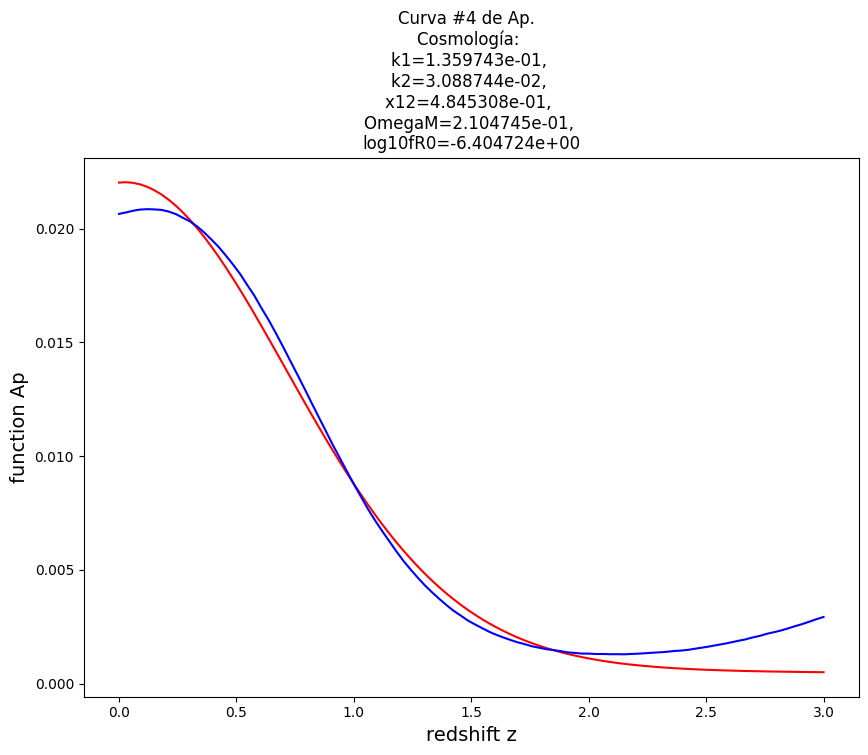

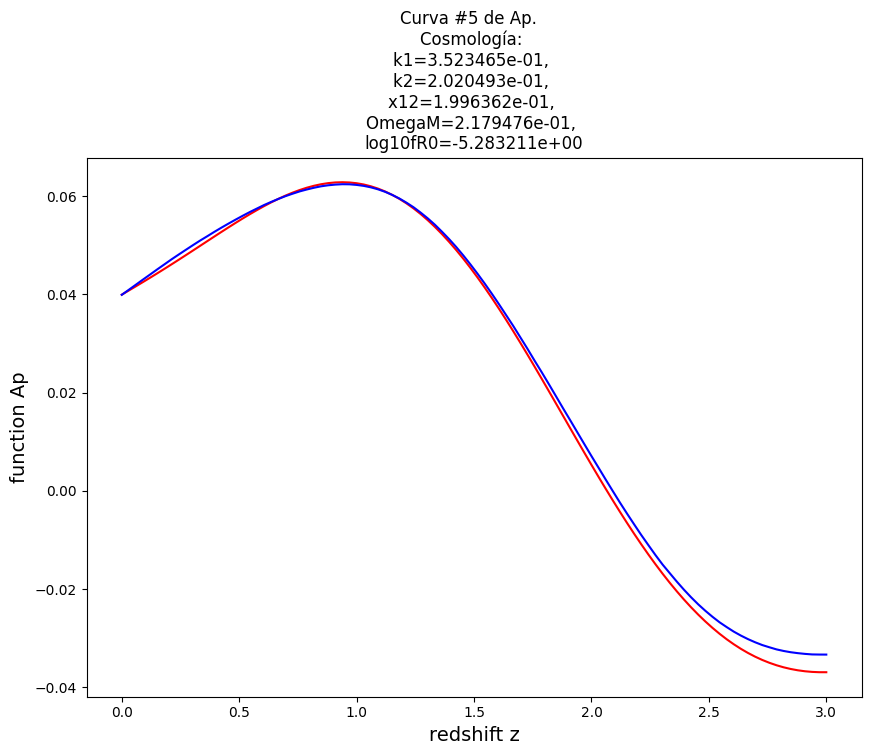

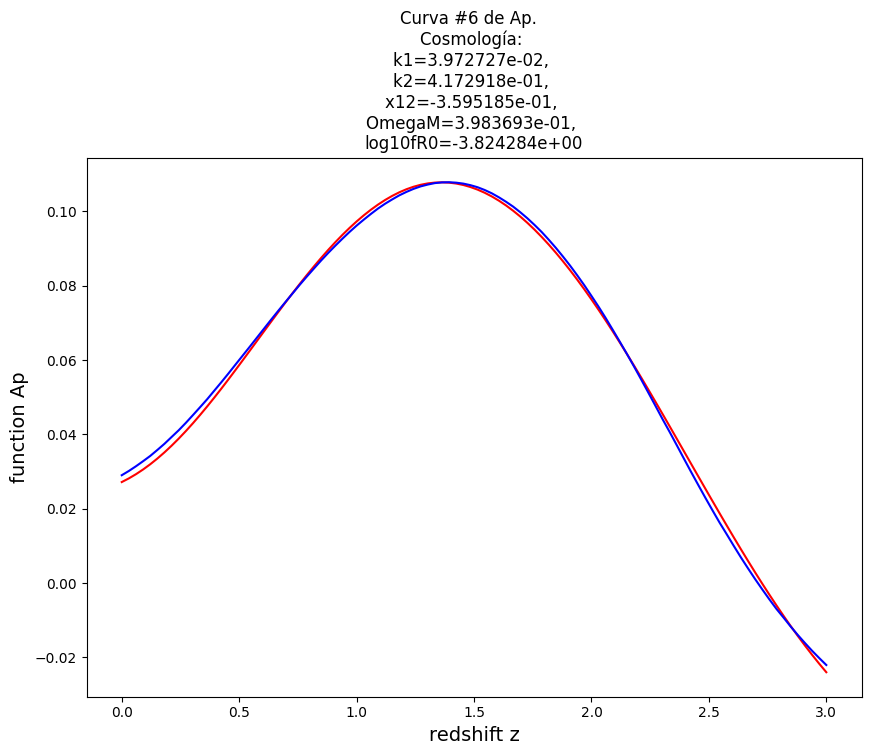

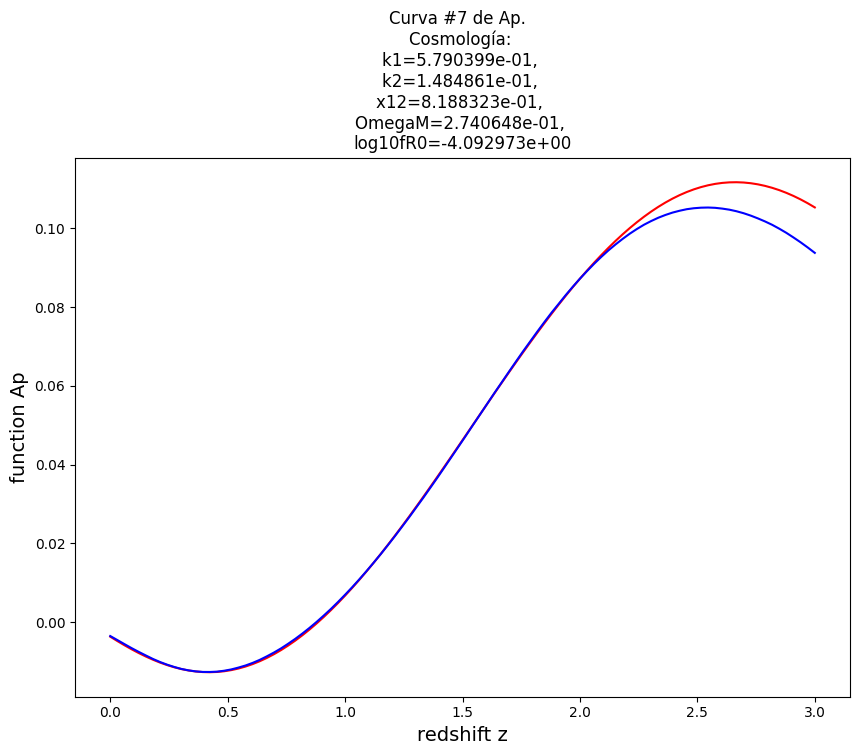

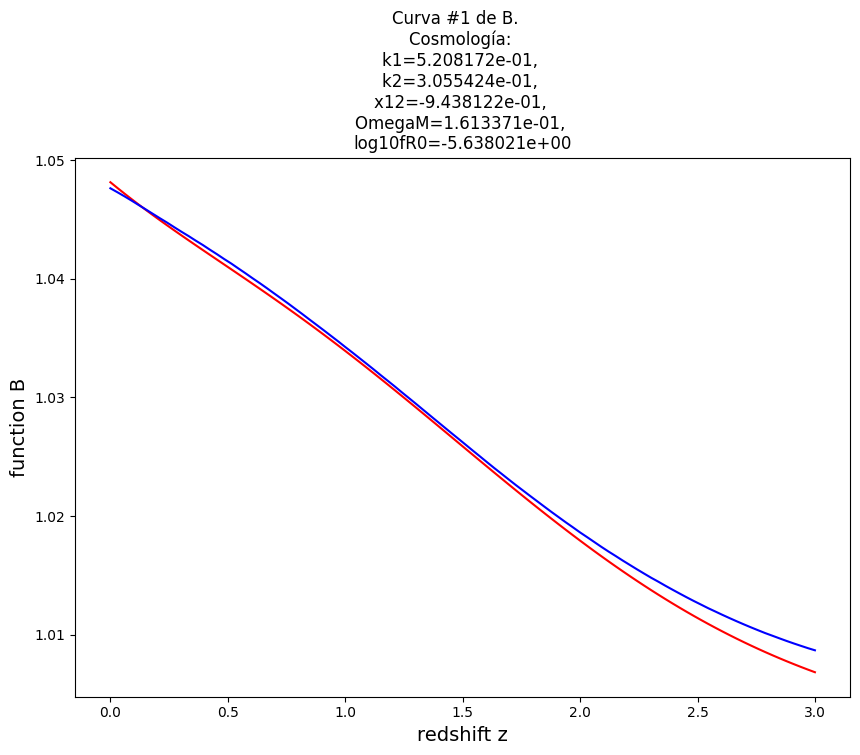

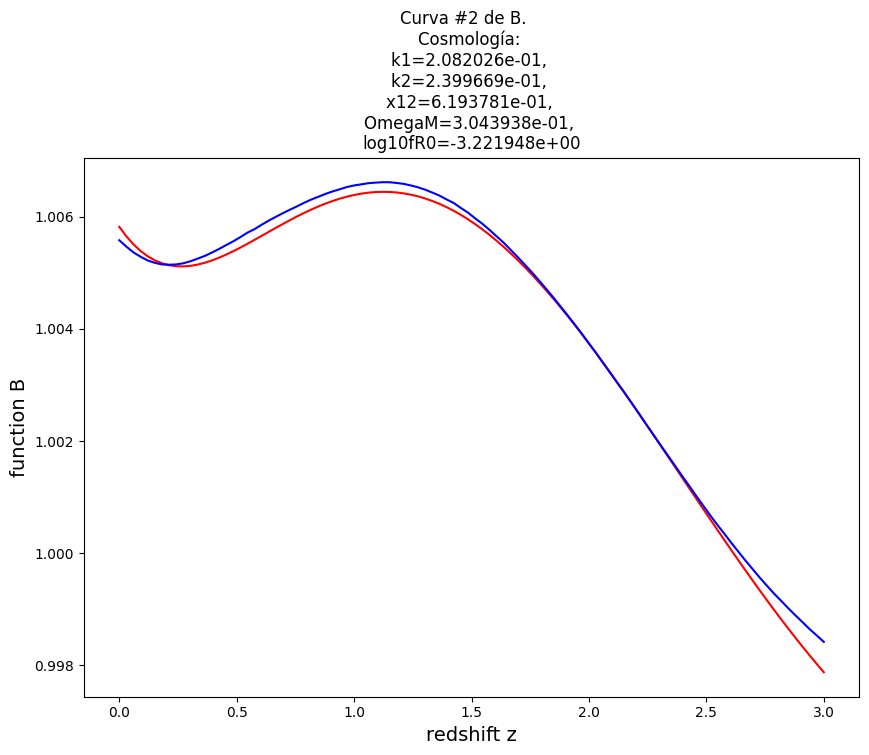

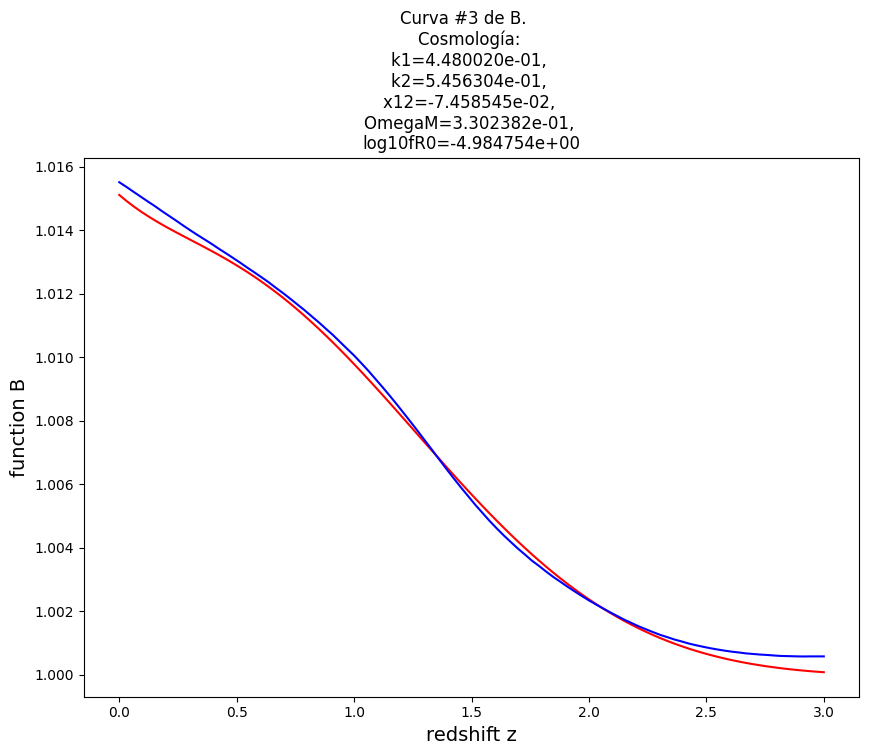

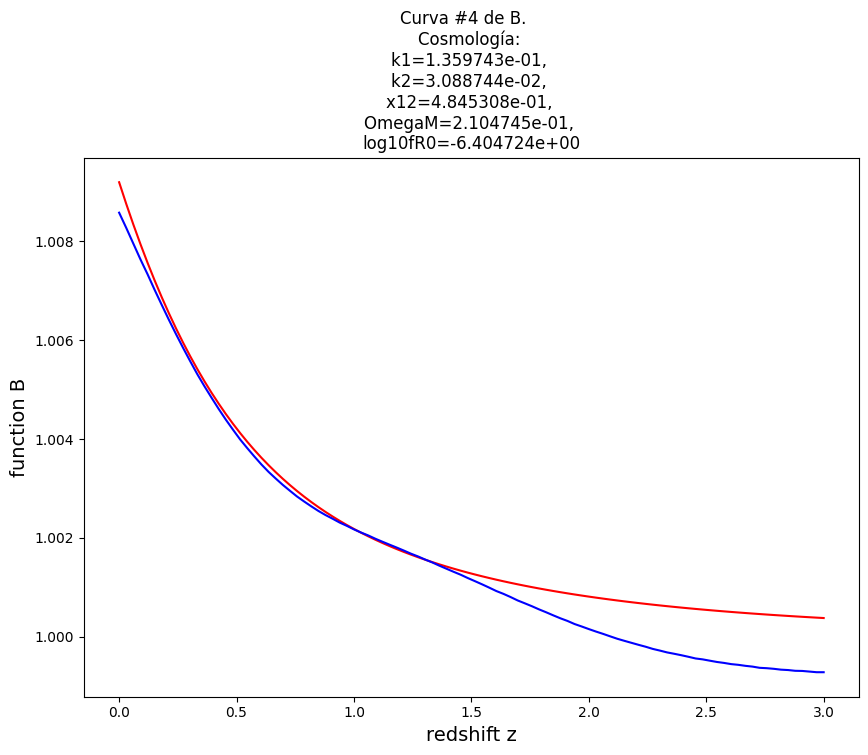

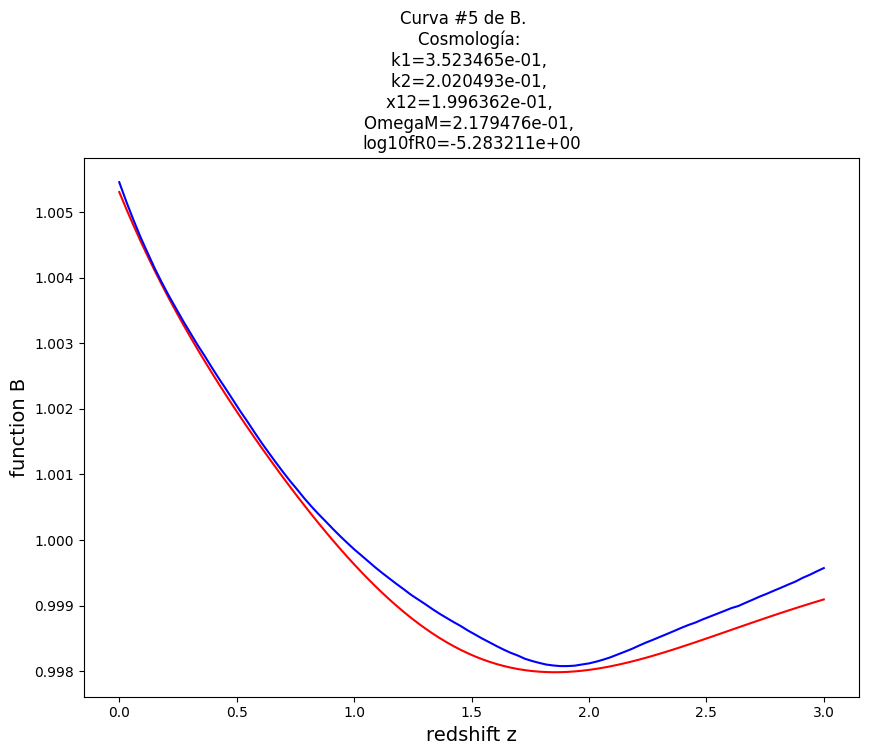

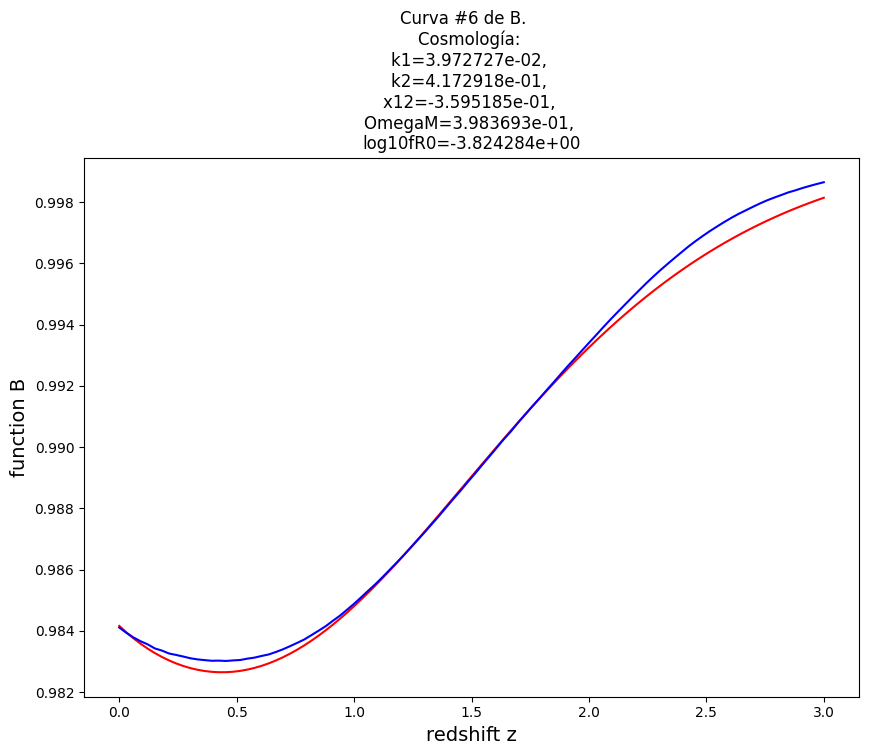

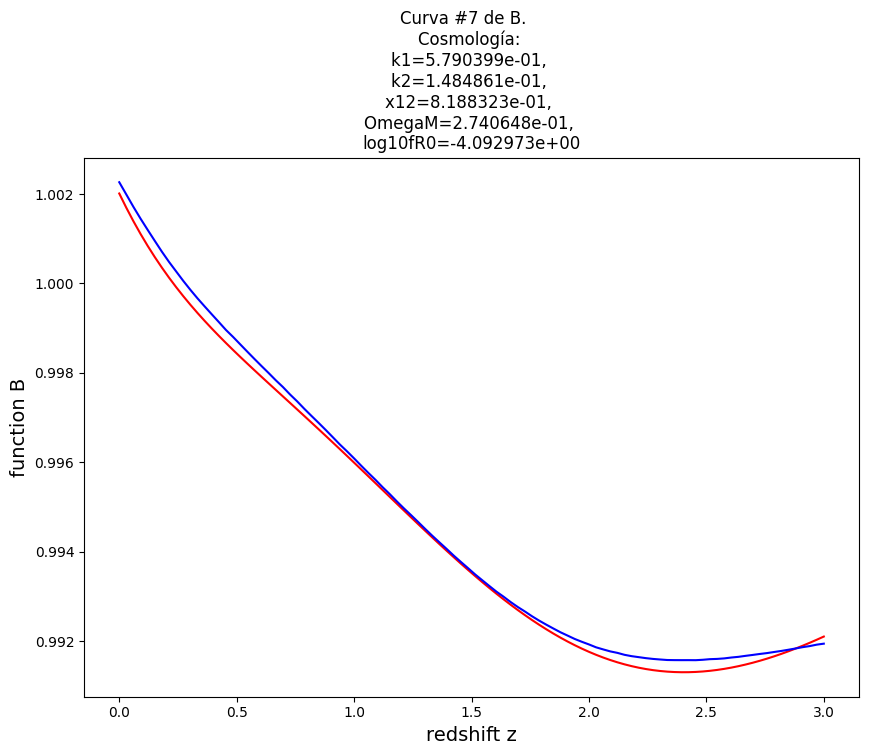

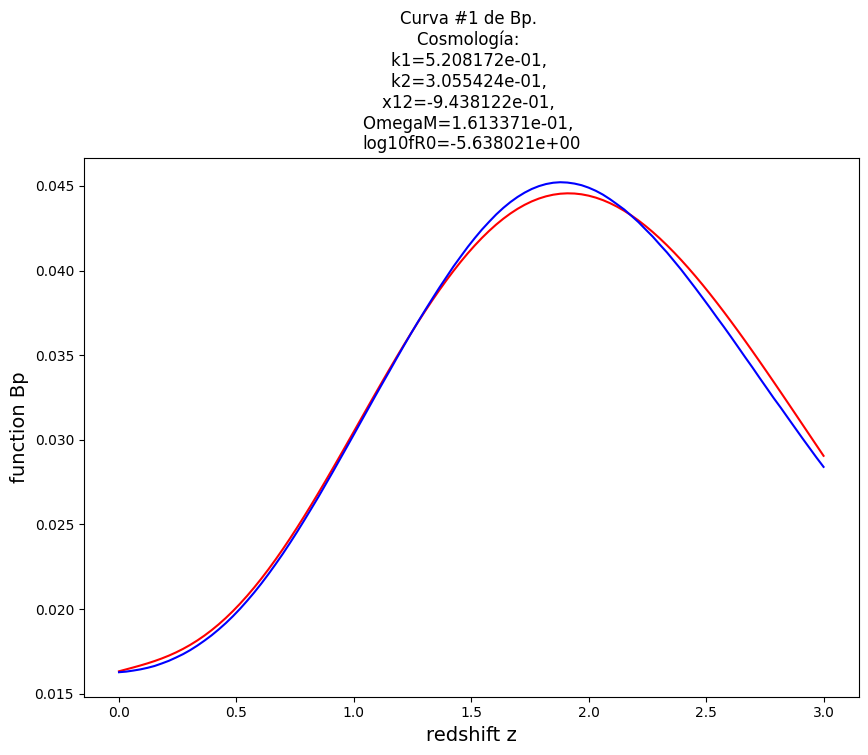

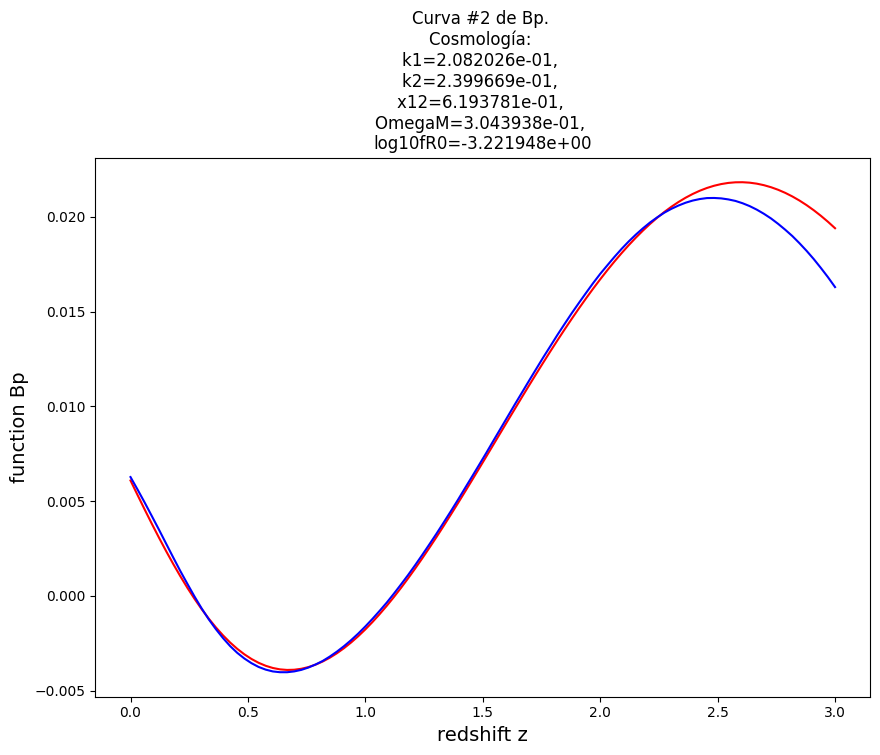

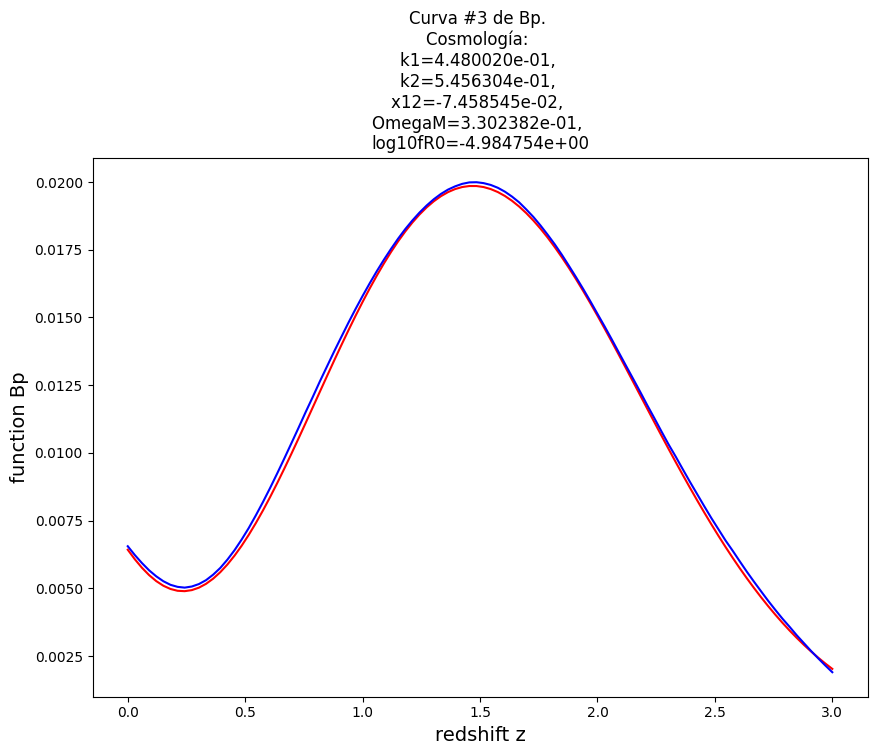

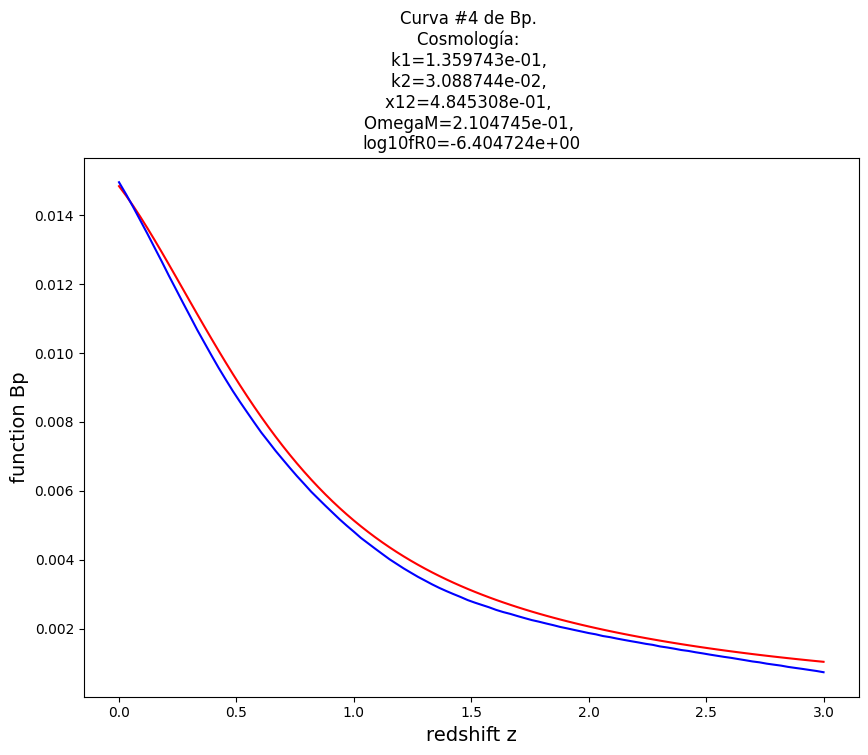

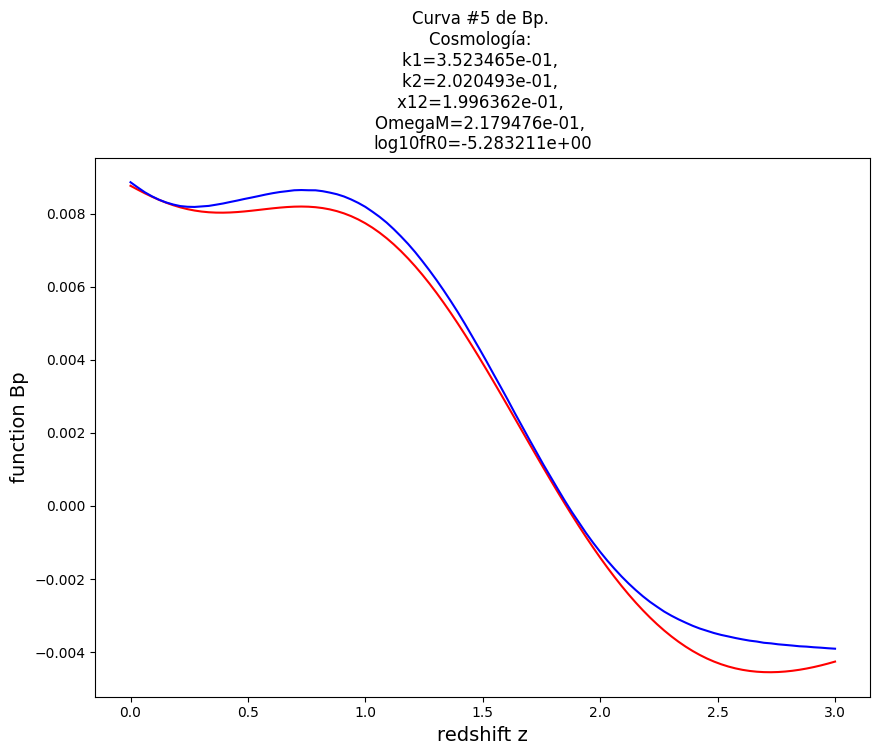

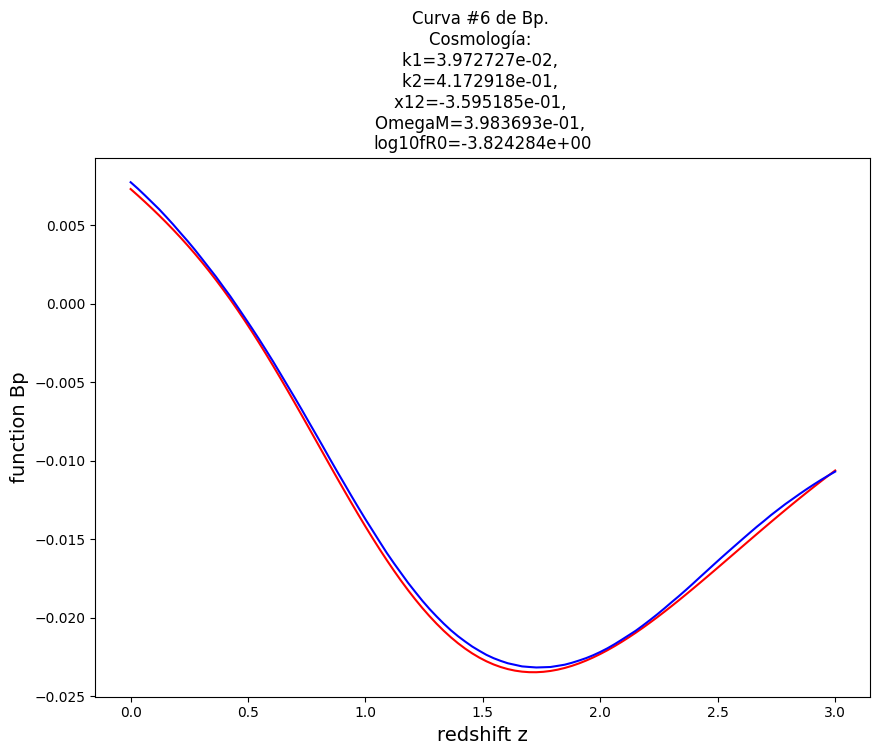

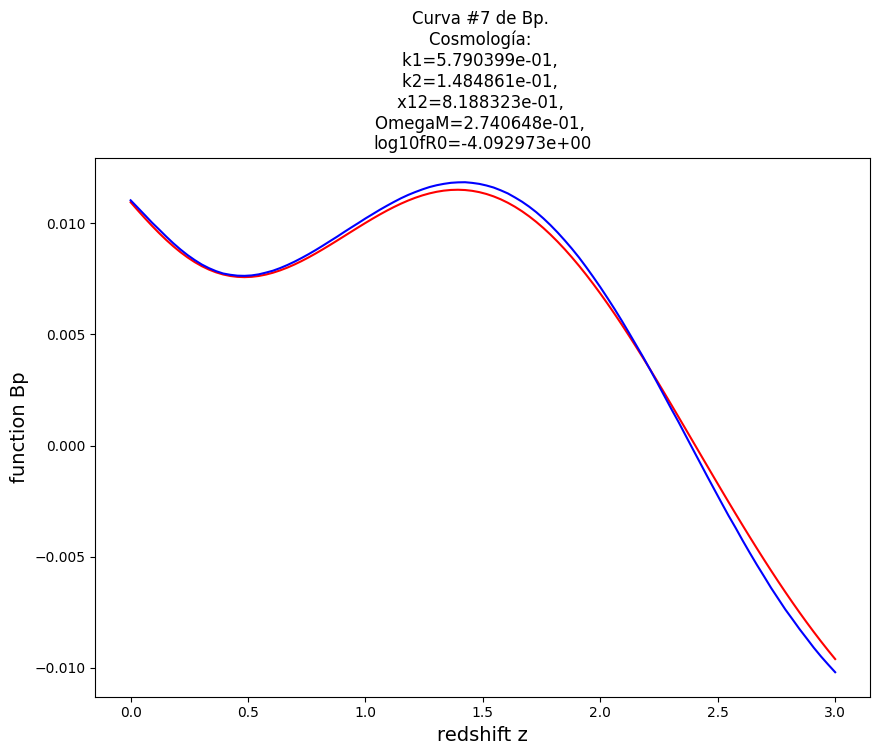

In [21]:
for p in range(7):
    plt.figure(figsize=(10,7))
    plt.plot(
        z_arr, A_arr[p],
        c="r",
        label="real"
    )
    plt.plot(
        z_arr, A_arr_predic[p],
        c="b",
        label="predic"
    )
    plt.xlabel("redshift z", fontsize=14)
    plt.ylabel("function A", fontsize=14)
    plt.legend()
    plt.title(f"Curva #{p + 1} de A.  \nCosmología: \nk1={cosmo[p][1]:.6e}, \nk2={cosmo[p][2]:.6e}, \nx12={cosmo[p][3]:.6e}, \nOmegaM={cosmo[p][4]:.6e}, \nlog10fR0={cosmo[p][5]:.6e}")
    plt.show()

print(60*"=")

for p in range(7):
    plt.figure(figsize=(10,7))
    plt.plot(
        z_arr, Ap_arr[p],
        c="r"
    )
    plt.plot(
        z_arr, Ap_arr_predic[p],
        c="b"
    )
    plt.xlabel("redshift z", fontsize=14)
    plt.ylabel("function Ap", fontsize=14)
    plt.title(f"Curva #{p + 1} de Ap.  \nCosmología: \nk1={cosmo[p][1]:.6e}, \nk2={cosmo[p][2]:.6e}, \nx12={cosmo[p][3]:.6e}, \nOmegaM={cosmo[p][4]:.6e}, \nlog10fR0={cosmo[p][5]:.6e}")
    plt.show()

print(60*"=")

for p in range(7):
    plt.figure(figsize=(10,7))
    plt.plot(
        z_arr, B_arr[p],
        c="r"
    )
    plt.plot(
        z_arr, B_arr_predic[p],
        c="b"
    )
    plt.xlabel("redshift z", fontsize=14)
    plt.ylabel("function B", fontsize=14)
    plt.title(f"Curva #{p + 1} de B.   \nCosmología: \nk1={cosmo[p][1]:.6e}, \nk2={cosmo[p][2]:.6e}, \nx12={cosmo[p][3]:.6e}, \nOmegaM={cosmo[p][4]:.6e}, \nlog10fR0={cosmo[p][5]:.6e}")
    plt.show()

print(60*"=")

for p in range(7):
    plt.figure(figsize=(10,7))
    plt.plot(
        z_arr, Bp_arr[p],
        c="r"
    )
    plt.plot(
        z_arr, Bp_arr_predic[p],
        c="b"
    )
    plt.xlabel("redshift z", fontsize=14)
    plt.ylabel("function Bp", fontsize=14)
    plt.title(f"Curva #{p + 1} de Bp. \nCosmología: \nk1={cosmo[p][1]:.6e}, \nk2={cosmo[p][2]:.6e}, \nx12={cosmo[p][3]:.6e}, \nOmegaM={cosmo[p][4]:.6e}, \nlog10fR0={cosmo[p][5]:.6e}")
    plt.show()